In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC

import seaborn as sea
import matplotlib.pyplot as plt

## Load the dataset
df = pd.read_csv('../data/merged.csv', sep=";")

df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [42]:
## Drop unnecessary features
df.drop(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'higher', 'famrel', 'freetime', 'goout', 'health', 'activities', 'internet', 'romantic', 'famsup', 'nursery', 'paid'], axis=1, inplace=True)

df.head(10)

,age,Medu,Fedu,traveltime,studytime,failures,schoolsup,Dalc,Walc,absences,G1,G2,G3
0,18,4,4,2,2,0,yes,1,1,4,0,11,11
1,17,1,1,1,2,0,no,1,1,2,9,11,11
2,15,1,1,1,2,0,yes,2,3,6,12,13,12
3,15,4,2,1,3,0,no,1,1,0,14,14,14
4,16,3,3,1,2,0,no,1,2,0,11,13,13
5,16,4,3,1,2,0,no,1,2,6,12,12,13
6,16,2,2,1,2,0,no,1,1,0,13,12,13
7,17,4,4,2,2,0,yes,1,1,2,10,13,13
8,15,3,2,1,2,0,no,1,1,0,15,16,17
9,15,3,4,1,2,0,no,1,1,0,12,12,13


<Axes: xlabel='risk_category', ylabel='count'>

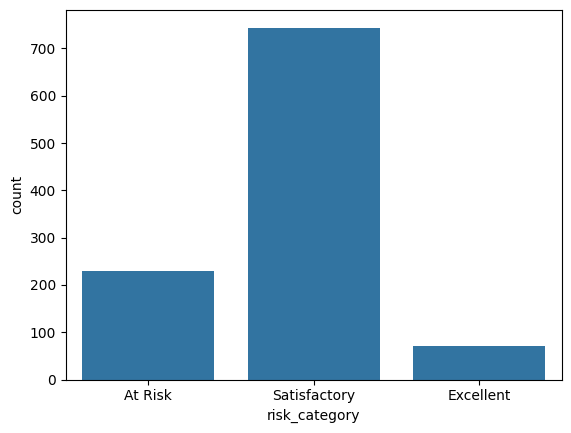

In [43]:
## Convert the continuous grade value into categorical ranges
bins = [0, 9, 16, 20]
labels = ['At Risk', 'Satisfactory', 'Excellent']

df['risk_category'] = pd.cut(df['G3'], bins=bins, labels=labels, include_lowest=True)

sea.countplot(data=df, x="risk_category")

In [44]:
## Change each category to a numerical value for the target feature and drop the columns
risk_cat_map = {
    'At Risk': 0,
    'Satisfactory': 1,
    'Excellent': 2
}

df['target'] = df['risk_category'].map(risk_cat_map)

df.drop(['G3', 'risk_category'], axis=1, inplace=True)

## Feature Engineering
df['grade_trajectory'] = df['G2'] - df['G1']
df['weighted_grade'] = 0.4*df['G1'] + 0.6*df['G2']
df['study_efficiency'] = df['G2'] / (df['studytime'] + 1)
df['absence_grade_interaction'] = df['absences']*(df['G1'] + df['G2'])

df.head()

,age,Medu,Fedu,traveltime,studytime,failures,schoolsup,Dalc,Walc,absences,G1,G2,target,grade_trajectory,weighted_grade,study_efficiency,absence_grade_interaction
0,18,4,4,2,2,0,yes,1,1,4,0,11,1,11,6.6,3.666667,44
1,17,1,1,1,2,0,no,1,1,2,9,11,1,2,10.2,3.666667,40
2,15,1,1,1,2,0,yes,2,3,6,12,13,1,1,12.6,4.333333,150
3,15,4,2,1,3,0,no,1,1,0,14,14,1,0,14.0,3.500000,0
4,16,3,3,1,2,0,no,1,2,0,11,13,1,2,12.2,4.333333,0


In [45]:
## Separate independent features from dependent variables
X = df.drop(['target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

numerical_cols = ['age', 'G1', 'G2', 'failures', 'absences', 'grade_trajectory', 'weighted_grade', 'study_efficiency', 'absence_grade_interaction']
intensity_cols = ['Medu', 'Fedu', 'traveltime', 'studytime', 'Dalc', 'Walc']
categorical_cols = ['schoolsup']


numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
intensity_transformer = Pipeline(steps=[
    ('minmax', MinMaxScaler())
])
categorical_transformer = Pipeline(steps=[
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('numerical', numerical_transformer, numerical_cols),
    ('intensity', intensity_transformer, intensity_cols),
    ('categorical', categorical_transformer, categorical_cols)
])

n_before_cat = len(numerical_cols) + len(intensity_cols)
categorical_col_indices = list(range(n_before_cat, n_before_cat + len(categorical_cols)))

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smotenc', SMOTENC(categorical_features=categorical_col_indices, random_state=42)),
    ('classifier', GradientBoostingClassifier(learning_rate=0.05, max_depth=3, subsample=1, n_estimators=200))
])

model.fit(X_train, y_train)


""" smotenc_step = model.named_steps['smotenc']
preprocessor_train = model.named_steps['preprocessor'].transform(X_train)
X_resampled, y_resampled = smotenc_step.fit_resample(preprocessor_train, y_train)

sea.countplot(data=y_resampled) """

y_pred = model.predict(X_test)

## Lowering the decision threshold for the At Risk class
y_prob = model.predict_proba(X_test)
class_order = model.classes_

at_risk_idx = list(class_order).index(0)

y_pred_adjusted = []

for prob in y_prob:
    if prob[at_risk_idx] >= 0.35:
        y_pred_adjusted.append(0)
    else:
        y_pred_adjusted.append(class_order[prob.argmax()])

              precision    recall  f1-score   support

     At Risk       0.77      0.89      0.83        46
Satisfactory       0.96      0.91      0.93       149
   Excellent       0.93      0.93      0.93        14

    accuracy                           0.91       209
   macro avg       0.89      0.91      0.90       209
weighted avg       0.92      0.91      0.91       209



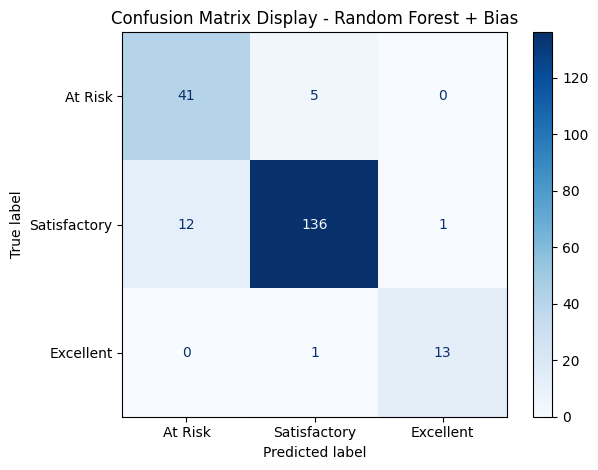

In [46]:
## Evaluation
labels = ['At Risk', 'Satisfactory', 'Excellent']

print(classification_report(y_test, y_pred_adjusted, target_names=labels))

cm = confusion_matrix(y_test, y_pred_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix Display - Random Forest + Bias')
plt.tight_layout()
plt.show()

In [29]:
## Getting the feature importance helped me decide on which features to drop
features = numerical_cols + intensity_cols + categorical_cols
rf_model = model.named_steps['classifier']
importance_df = pd.DataFrame({
    'features': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

                     features  importance
2                          G2    0.672143
6              weighted_grade    0.241473
10                       Fedu    0.011978
9                        Medu    0.011293
11                 traveltime    0.010955
7            study_efficiency    0.009854
1                          G1    0.005632
5            grade_trajectory    0.005577
0                         age    0.005193
12                  studytime    0.004971
4                    absences    0.004230
8   absence_grade_interaction    0.004100
13                       Dalc    0.003787
14                       Walc    0.003438
15                  schoolsup    0.003075
3                    failures    0.002300


In [47]:
# Note the 'classifier__' prefix — it tells GridSearchCV these params
# belong to the 'classifier' step inside your pipeline
search_configs = {
    'Random Forest': {
        'classifier': RandomForestClassifier(class_weight='balanced', random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [None, 10, 20],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 'log2']
        }
    },

    'Gradient Boosting': {
        'classifier': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__max_depth': [3, 5],
            'classifier__learning_rate': [0.05, 0.1, 0.2],
            'classifier__subsample': [0.8, 1.0]
        }
    },

    'Logistic Regression': {
        'classifier': LogisticRegression(
            max_iter=1000, 
            class_weight='balanced', 
            random_state=42
        ),
        'params': {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__solver': ['lbfgs', 'saga']
        }
    },

    'SVM': {
        'classifier': SVC(class_weight='balanced', probability=True, random_state=42),
        'params': {
            'classifier__C': [0.1, 1, 10],
            'classifier__kernel': ['rbf', 'linear'],
            'classifier__gamma': ['scale', 'auto']
        }
    }
}

results = []

grid_searches = {}

for model_name, config in search_configs.items():

    fresh_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('smotenc', SMOTENC(categorical_features=categorical_col_indices, random_state=42)),
        ('classifier', config['classifier'])
    ])

    gs = GridSearchCV(
        estimator=fresh_pipeline,
        param_grid=config['params'],
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=2
    )

    gs.fit(X_train, y_train)
    grid_searches[model_name] = gs

    results.append({
        'Model': model_name,
        'Best CV Macro F1': gs.best_score_,
        'Best Params': gs.best_params_,
        'Best Estimator': gs.best_estimator_
    })


results_df = pd.DataFrame(results)[['Model', 'Best CV Macro F1']]
print(results_df.sort_values('Best CV Macro F1', ascending=False))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 12 candidates, totalling 60 fits
                 Model  Best CV Macro F1
0        Random Forest          0.852539
1    Gradient Boosting          0.850285
2  Logistic Regression          0.820135
3                  SVM          0.807395


{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
              precision    recall  f1-score   support

     At Risk       0.77      0.80      0.79        46
Satisfactory       0.93      0.92      0.93       149
   Excellent       0.93      0.93      0.93        14

    accuracy                           0.89       209
   macro avg       0.88      0.88      0.88       209
weighted avg       0.90      0.89      0.90       209



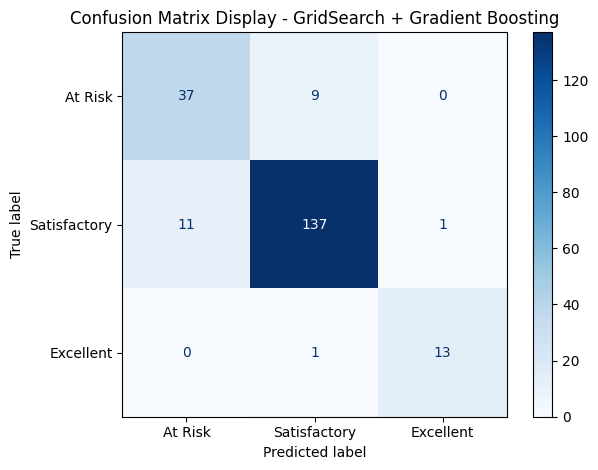

In [48]:
print(grid_searches['Random Forest'].best_params_)

grid_pred = grid_searches['Random Forest'].predict(X_test)

labels = ['At Risk', 'Satisfactory', 'Excellent']

## Evaluation
print(classification_report(y_test, grid_pred, target_names=labels))

cm = confusion_matrix(y_test, grid_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix Display - GridSearch + Gradient Boosting')
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

     At Risk       0.75      0.89      0.81        46
Satisfactory       0.96      0.89      0.92       149
   Excellent       0.87      0.93      0.90        14

    accuracy                           0.89       209
   macro avg       0.86      0.90      0.88       209
weighted avg       0.90      0.89      0.90       209



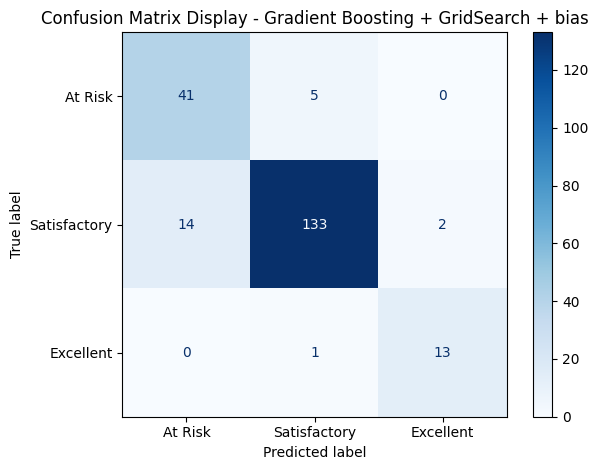

In [ ]:
## Lowering the decision threshold for the At Risk class
grid_proba = grid_searches['Gradient Boosting'].predict_proba(X_test)

class_order = grid_searches['Gradient Boosting'].classes_
at_risk_idx = list(class_order).index(0)

grid_pred_adjusted = []

for prob in grid_proba:
    if prob[at_risk_idx] >= 0.35:
        grid_pred_adjusted.append(0)
    else:
        grid_pred_adjusted.append(class_order[prob.argmax()])

## Evaluation
labels = ['At Risk', 'Satisfactory', 'Excellent']

print(classification_report(y_test, grid_pred_adjusted, target_names=labels))

cm = confusion_matrix(y_test, grid_pred_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix Display - Gradient Boosting + GridSearch + bias')
plt.tight_layout()
plt.show()

In [ ]:
## Applying the bias on the grid_search model

grid_proba = grid_searches['Gradient Boosting'].predict_proba(X_test)

class_order = grid_searches['Gradient Boosting'].classes_
at_risk_idx = list(class_order).index(0)

thresholds = np.arange(0.20, 0.55, 0.05)
results = []


for threshold in thresholds:

    grid_pred_adjusted = []
    for prob in grid_proba:
        if prob[at_risk_idx] >= 0.35:
            grid_pred_adjusted.append(0)
        else:
            grid_pred_adjusted.append(class_order[prob.argmax()])

    macro_f1 = f1_score(y_test, grid_pred_adjusted, average='macro')
    at_risk_recall = sum(
        1 for true, pred in zip(y_test, grid_pred_adjusted)
        if true == 0 and pred == 0
    ) / sum(1 for true in y_test if true == 0)

    results.append({
        'Threshold': round(threshold, 2),
        'Macro F1': round(macro_f1, 4),
        'At Risk Recall': round(at_risk_recall, 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

print(classification_report(y_test, grid_pred_adjusted, target_names=labels))

""" cm = confusion_matrix(y_test, grid_pred_adjusted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix Display - GridSearchCV + Threshold Tuning')
plt.tight_layout()
plt.show() """

proba_df = pd.DataFrame({
    'true_label': y_test,
    'at_risk_proba': grid_proba[:, at_risk_idx],
    'predicted': grid_searches['Gradient Boosting'].predict(X_test)
})

## Threshold Diagnosis
# Focus specifically on the students the model is getting wrong
missed_at_risk = proba_df[
    (proba_df['true_label'] == 0) &  # actually At Risk
    (proba_df['predicted'] != 0)      # predicted as something else
]

print(missed_at_risk[['true_label', 'at_risk_proba', 'predicted']])

NameError: name 'grid_searches' is not defined